## Регуляризация в регрессии

Регуляризация — метод предотвращения переобучения путём штрафа за большие коэффициенты модели.

### Ridge Regression (L2-регуляризация)

Штраф: сумма квадратов весов  
$$
\min \left( \sum (y - \hat{y})^2 + \lambda \sum w_i^2 \right)
$$

Эффект:
- уменьшает веса
- **не** зануляет признаки
- даёт стабильную модель

### Lasso Regression (L1-регуляризация) - Least Absolute Shrinkage and Selection Operator

Штраф: сумма модулей весов  
$$
\min \left( \sum (y - \hat{y})^2 + \lambda \sum |w_i| \right)
$$

Эффект:
- может занулить коэффициенты
- делает feature selection

### Когда что использовать?

| Метод | Использовать когда |
|-------|-------------------|
| **Ridge (L2)** | много признаков, нужны все |
| **Lasso (L1)** | надо выбрать важные признаки |
| **ElasticNet** | смесь L1 и L2, полезно при коррелированных признаках |


## Регуляризация в полиномиальной регрессии
### Ridge (L2), Lasso (L1), ElasticNet (L1+L2)

Цель: показать влияние регуляризации на модель высокой степени и предотвратить переобучение.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import scale
from scipy.constants import degree

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error


In [4]:
# Генерация данных (кубическая зависимость)
np.random.seed(42)
n = 120
X = np.linspace(-4, 6, n).reshape(-1, 1)
noise = np.random.normal(0, 6, size=n)
y = 0.5*X[:,0]**3 - 3*X[:,0]**2 + 2*X[:,0] + noise

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [5]:
def train_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print(f"R^2 score: {r2_score(y_test, y_pred):.4f}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f} ")
    return model

In [9]:
degree = 10
ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

lasso = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ("scale", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=1000)),
])

elastic = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ("scale", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.05, max_iter=1000, l1_ratio=0.3)),
])

ridge = train_model(ridge, "Ridge (L2)")
lasso = train_model(lasso, "Lasso (L1)")
elastic = train_model(elastic, "ElasticNet (L1 + L2)")

=== Ridge (L2) ===
R^2 score: 0.9472
RMSE: 5.6133 
=== Lasso (L1) ===
R^2 score: 0.9528
RMSE: 5.3085 
=== ElasticNet (L1 + L2) ===
R^2 score: 0.9500
RMSE: 5.4631 


C:\Users\zamanov\Documents\AI-FSDE_1_24_3_ru\AI 08\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.252e+00, tolerance: 3.845e+00
  model = cd_fast.enet_coordinate_descent(


- Ridge -
- Lasso -
- ElasticNet -

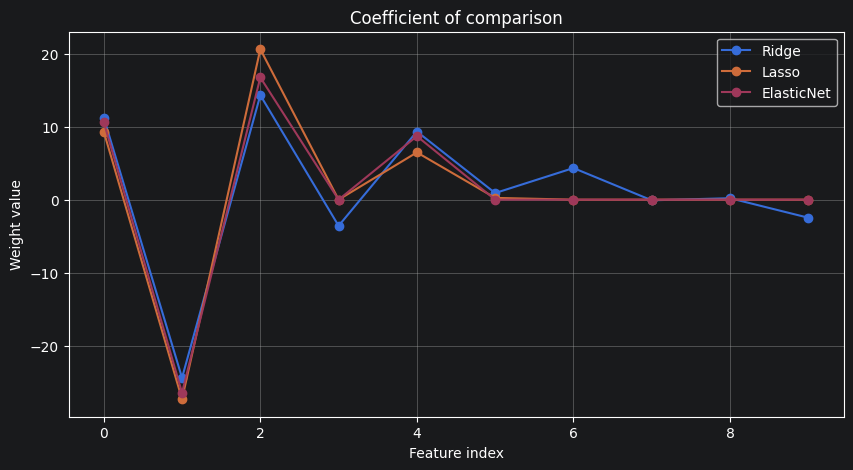

In [11]:
models = {
    "Ridge": ridge.named_steps["ridge"].coef_,
    "Lasso": lasso.named_steps["lasso"].coef_,
    "ElasticNet": elastic.named_steps["elastic"].coef_,
}

plt.figure(figsize=(10, 5))
for name, coef in models.items():
    plt.plot(coef, marker='o', label=name)

plt.title("Coefficient of comparison")
plt.xlabel("Feature index")
plt.ylabel("Weight value")
plt.legend()
plt.grid(True)
plt.show()